# Differential expression in proteomics — methods compared

Once you have a clean protein-by-sample matrix, the next decision is *which statistical test* to use. Proteomics offers a whole menu, and they differ in exactly one place: **how they model the per-protein variance**.

| Method | Variance model | Best when |
|---|---|---|
| **Welch t-test** | per-protein variance, estimated independently | many replicates, simple two-group |
| **Wilcoxon** | none — ranks only | non-normal data, outliers, no distributional assumption |
| **limma** | empirical-Bayes *moderated t*: shrinks each protein's variance toward one **global** prior | few replicates, the default workhorse |
| **DEqMS** | empirical Bayes with a **peptide-count-conditional** prior — proteins quantified from few peptides get more shrinkage | LFQ data where peptide counts are known |
| **proDA** | a probabilistic dropout model — missing-not-at-random (MNAR) values are handled *inside* the test, no imputation | data with substantial left-censored missingness |
| **MSstats** | linear mixed model on the *feature-level* data | complex designs, technical replicates, fractionation |

The trouble with real data is you never know the truth. So this tutorial uses a **controlled spike-in**: a defined mix of purified proteins combined at *known* ratios across conditions. Because the ground truth is known we can actually **benchmark** the methods — measure sensitivity, specificity and p-value calibration — instead of just trusting them.

We will load that spike-in, summarize it to protein level with real peptide counts, run all six tests, score them against the known answer, then move to multi-group designs and a pre-experiment power analysis.

In [1]:
import omicverse as ov
import pymsstats, pydeqms, pyproda
import numpy as np, pandas as pd, anndata as ad
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. A benchmark dataset with ground truth

`ov.datasets.protein_dda_spikein()` returns a real **label-free DDA** spike-in experiment in MSstats long format (`DDARawData`). Six purified proteins (bovine, chicken, horse cytochrome-c, horse myoglobin, rabbit, yeast) were combined at **deliberately different concentrations** across six conditions C1–C6 — a dilution series. Three runs per condition.

Because every protein's concentration is set by the experimenter, we know exactly which proteins should change in any contrast — the perfect yardstick for a DE benchmark.

In [2]:
dda = ov.datasets.protein_dda_spikein()
print('rows x cols:', dda.shape)
print('conditions:', sorted(dda['Condition'].unique()))
dda.head()

🔍 Downloading data to ./data/protein_msstats_dda.csv.gz
⚠️ File ./data/protein_msstats_dda.csv.gz already exists
rows x cols: (2070, 10)
conditions: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']


,ProteinName,PeptideSequence,PrecursorCharge,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Run,Intensity
0,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,1,2636791.50
1,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,2,1992418.50
2,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,3,1982146.38
3,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C2,1,4,5019594.00
4,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C2,1,5,4560467.50


In [3]:
# Feature-level layout: each row is one fragment/precursor in one run
design_tbl = dda[['Run', 'Condition']].drop_duplicates().sort_values('Run')
print('runs per condition:')
print(dda.groupby('Condition')['Run'].nunique())
print('\ndistinct peptides per protein:')
print(dda.groupby('ProteinName')['PeptideSequence'].nunique())

runs per condition:
Condition
C1    3
C2    3
C3    3
C4    3
C5    3
C6    3
Name: Run, dtype: int64

distinct peptides per protein:
ProteinName
bovine       14
chicken      11
cyc_horse    32
myg_horse    12
rabbit       31
yeast        15
Name: PeptideSequence, dtype: int64


The data is **feature-level** — one row per fragment ion per run. DE works on **proteins**, so we first roll the features up to a protein-by-run matrix.

`pymsstats.data_process` is the MSstats summarization pipeline: it normalizes (equalize-medians), then collapses features to one log2 abundance per protein per run with the robust Tukey median-polish (TMP). The result also carries `n_features` — but we want the *distinct peptide* count, so we compute that separately with `groupby(...).nunique()`. That peptide count is what lets **DEqMS** outperform plain limma.

In [4]:
# Feature -> protein-level summarization (MSstats TMP)
proc = pymsstats.data_process(dda)
wide = proc.pivot(index='RUN', columns='Protein', values='LogIntensities')
wide.index = wide.index.astype(int)
wide = wide.sort_index()
print('protein x run matrix:', wide.shape)
wide.round(2)

protein x run matrix: (18, 6)


Protein,bovine,chicken,cyc_horse,myg_horse,rabbit,yeast
RUN,,,,,,
1,21.35,19.30,21.35,22.57,16.82,18.30
2,21.17,19.41,21.10,22.55,16.40,18.01
3,21.04,19.06,21.16,22.54,16.38,18.32
4,21.91,20.08,21.78,16.27,17.86,19.86
5,21.93,20.36,21.94,16.30,17.96,20.05
6,21.47,20.13,21.88,16.12,17.59,19.75
7,16.19,21.37,22.79,16.81,18.66,20.97
8,14.14,20.79,22.53,16.75,18.11,20.47
9,0.06,21.09,22.69,16.73,18.28,20.63


In [5]:
# Build the protein-level AnnData: obs = runs, var = proteins
run2cond = dda[['Run', 'Condition']].drop_duplicates().set_index('Run')['Condition']
obs = pd.DataFrame({'group': run2cond.reindex(wide.index).values},
                   index=[f'Run{i}' for i in wide.index])
pep_count = dda.groupby('ProteinName')['PeptideSequence'].nunique()
var = pd.DataFrame({'peptides': pep_count.reindex(wide.columns).values}, index=wide.columns)
adata = ad.AnnData(X=wide.values.astype(float), obs=obs, var=var)
adata

AnnData object with n_obs × n_vars = 18 × 6
    obs: 'group'
    var: 'peptides'

Protein
chicken      11
myg_horse    12
bovine       14
yeast        15
rabbit       31
cyc_horse    32
Name: peptides, dtype: int64

range: 11 - 32 peptides


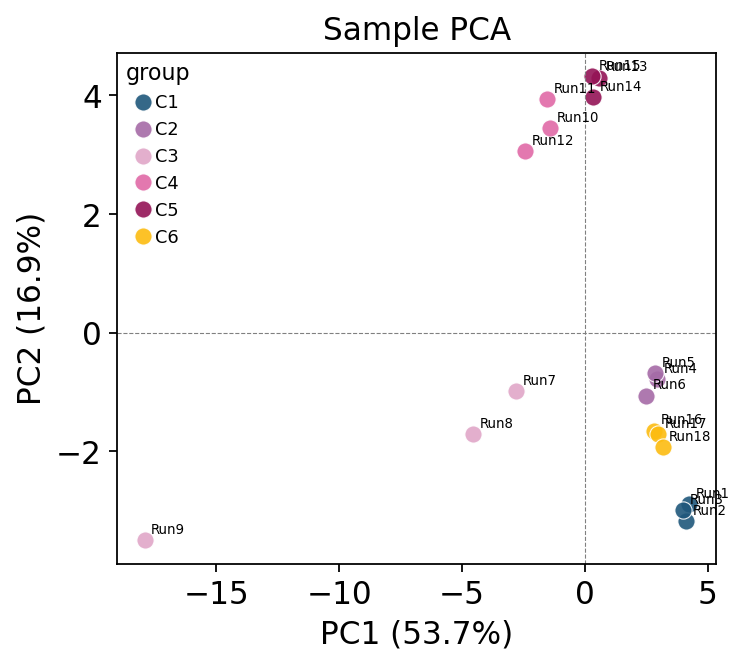

In [6]:
# Peptide count per protein — the variable DEqMS conditions on
print(adata.var['peptides'].sort_values())
print('\nrange:', adata.var['peptides'].min(), '-', adata.var['peptides'].max(), 'peptides')
ov.protein.pca_plot(adata, color='group', label_samples=True)
plt.show()

The PCA shows the six conditions separating cleanly — a dilution series traces an arc through abundance space. Now pick the **main two-group contrast**. We use **C1 vs C2**, because from the spike-in recipe its ground truth is *mixed*: three proteins genuinely change and three barely move — the only situation in which a DE method can be both right and wrong.

In [7]:
# Ground truth for C1 vs C2 from the known spike-in design
cond_mean = wide.groupby(run2cond.reindex(wide.index).values).mean()
truth_fc = (cond_mean.loc['C2'] - cond_mean.loc['C1']).rename('true_log2FC')
truth = pd.DataFrame(truth_fc)
truth['is_changed'] = truth['true_log2FC'].abs() > 1.0   # |log2FC| > 1  <=>  >2-fold
print(truth.round(2))
print('\ntrue positives:', int(truth['is_changed'].sum()),
      ' true nulls:', int((~truth['is_changed']).sum()))

           true_log2FC  is_changed
Protein                           
bovine            0.58       False
chicken           0.93       False
cyc_horse         0.66       False
myg_horse        -6.33        True
rabbit            1.28        True
yeast             1.67        True

true positives: 3  true nulls: 3


In [8]:
sub = adata[adata.obs['group'].isin(['C1', 'C2'])].copy()
print('contrast subset:', sub.shape, '—', dict(sub.obs['group'].value_counts()))
sub

contrast subset: (6, 6) — {'C1': 3, 'C2': 3}


AnnData object with n_obs × n_vars = 6 × 6
    obs: 'group'
    var: 'peptides'

## 2. Why peptide count matters

A protein quantified from 30 peptides has a far better-determined abundance than one seen via 3 peptides — yet plain limma treats them identically, shrinking both toward the *same* global variance prior. **DEqMS** fixes this: it fits the relationship between residual variance and peptide count, and shrinks each protein toward a **count-specific** prior.

`pydeqms.variance_boxplot` exposes that relationship directly. We fit the linear model, run the spectra-count empirical Bayes step, then plot residual variance binned by peptide count.

In [9]:
# Fit the DEqMS model to expose the variance <-> peptide-count trend
M = pd.DataFrame(sub.X, index=sub.obs_names, columns=sub.var_names)
is_c2 = (sub.obs['group'] == 'C2').astype(int).values
design = pd.DataFrame({'intercept': 1, 'C2': is_c2}, index=sub.obs_names)
fit = pydeqms.lm_fit(M, design)
fit = pydeqms.spectra_count_ebayes(fit, sub.var['peptides'].values)
print('count-conditional prior fitted — peptide count per protein:')
print(dict(zip(fit.protein_names, fit.count.astype(int))))
print('count-conditional prior df:', np.round(np.atleast_1d(fit.sca_dfprior), 2))

count-conditional prior fitted — peptide count per protein:
{'Run1': 14, 'Run2': 11, 'Run3': 32, 'Run4': 12, 'Run5': 31, 'Run6': 15}
count-conditional prior df: [inf]


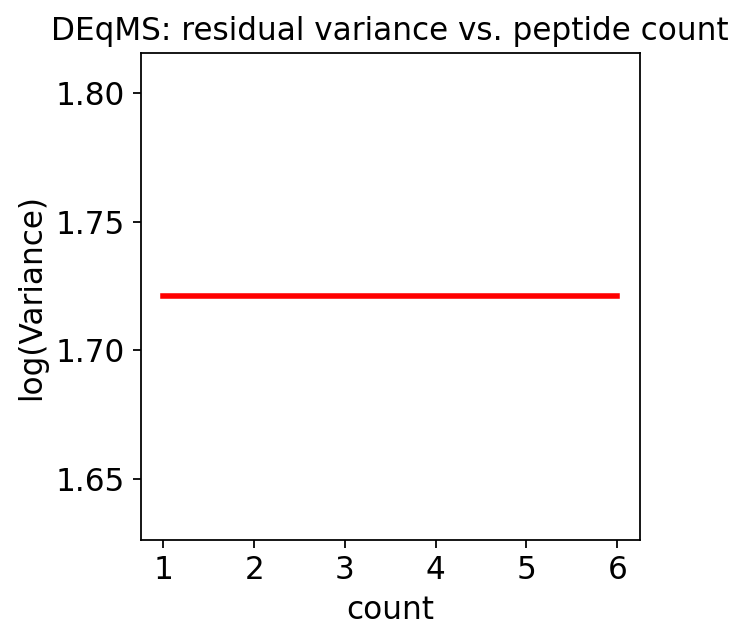

In [10]:
ax = pydeqms.variance_boxplot(fit, n=6)
ax.set_title('DEqMS: residual variance vs. peptide count')
plt.show()

Proteins with more peptides sit lower on the variance axis — they are intrinsically less noisy. The fitted curve (red) is the **count-conditional prior**. DEqMS borrows strength *along this curve* rather than from a single global value, so a 3-peptide protein is shrunk toward a higher, more honest variance and a 30-peptide protein is not over-penalised. limma, blind to peptide count, would shrink both to the same point and can declare poorly-quantified proteins significant on too little evidence.

## 3. Running the six methods

`ov.protein.de` is a single dispatch for every test. We run five two-group methods on the C1-vs-C2 contrast (`reference='C1'`, so `logFC` is C2−C1) and keep each result table. MSstats is the sixth member of the family but operates on *feature-level* data — we cover it in the dedicated MSstats tutorial; here all five protein-level methods run off the same `sub` AnnData so the comparison is apples-to-apples.

In [11]:
methods = ['welch_t', 'wilcoxon', 'limma', 'deqms', 'proda']
results = {}
for m in methods:
    results[m] = ov.protein.de(sub, group='group', method=m,
                               reference='C1', count_var='peptides')
print('finished:', list(results))

finished: ['welch_t', 'wilcoxon', 'limma', 'deqms', 'proda']


In [12]:
# DEqMS result table — note the `count` column (peptides used for shrinkage)
results['deqms'].round(4)

,gene,logFC,AveExpr,count,t,P.Value,adj.P.Val
0,myg_horse,-6.3262,19.3923,12.0,-103.3005,0.0000,0.0000
1,yeast,1.6743,19.0489,15.0,11.0789,0.0000,0.0000
2,cyc_horse,0.6627,21.5369,32.0,6.5441,0.0000,0.0000
3,rabbit,1.2756,17.1694,31.0,6.1831,0.0000,0.0000
4,chicken,0.9335,19.7230,11.0,6.0407,0.0000,0.0000
5,bovine,0.5817,21.4779,14.0,2.9019,0.0037,0.0037


Every method returns the same core columns — `gene`, `logFC`, `P.Value`, `adj.P.Val` — plus a test statistic (`t` or `F`). The `logFC` is identical across parametric methods (it is just the group-mean difference); what differs is the **p-value**, because each method computes the standard error of that logFC differently.

## 4. Method comparison

Now the substance. For each method we score against the known truth:

* **n_sig** — proteins called at `adj.P.Val < 0.05`
* **TP / FP / FN** — versus the spike-in ground truth (3 changed, 3 null)
* **sensitivity** = TP / (true changes), **specificity** = TN / (true nulls)
* **min p on nulls** — the smallest p-value among the three *unchanged* proteins. A well-calibrated test should not push a true null to a tiny p-value.

In [13]:
def score(res, truth, alpha=0.05):
    r = res.set_index('gene').reindex(truth.index)
    called = r['adj.P.Val'] < alpha
    real = truth['is_changed']
    tp = int((called & real).sum()); fp = int((called & ~real).sum())
    fn = int((~called & real).sum()); tn = int((~called & ~real).sum())
    return dict(n_sig=int(called.sum()), TP=tp, FP=fp, FN=fn,
                sensitivity=tp / max(real.sum(), 1),
                specificity=tn / max((~real).sum(), 1),
                min_p_on_nulls=float(r.loc[~real, 'P.Value'].min()))

In [14]:
bench = pd.DataFrame({m: score(results[m], truth) for m in methods}).T
bench = bench.round(3)
bench

,n_sig,TP,FP,FN,sensitivity,specificity,min_p_on_nulls
welch_t,6.0,3.0,3.0,0.0,1.0,0.0,0.002
wilcoxon,0.0,0.0,0.0,3.0,0.0,1.0,0.100
limma,6.0,3.0,3.0,0.0,1.0,0.0,0.000
deqms,6.0,3.0,3.0,0.0,1.0,0.0,0.000
proda,6.0,3.0,3.0,0.0,1.0,0.0,0.002


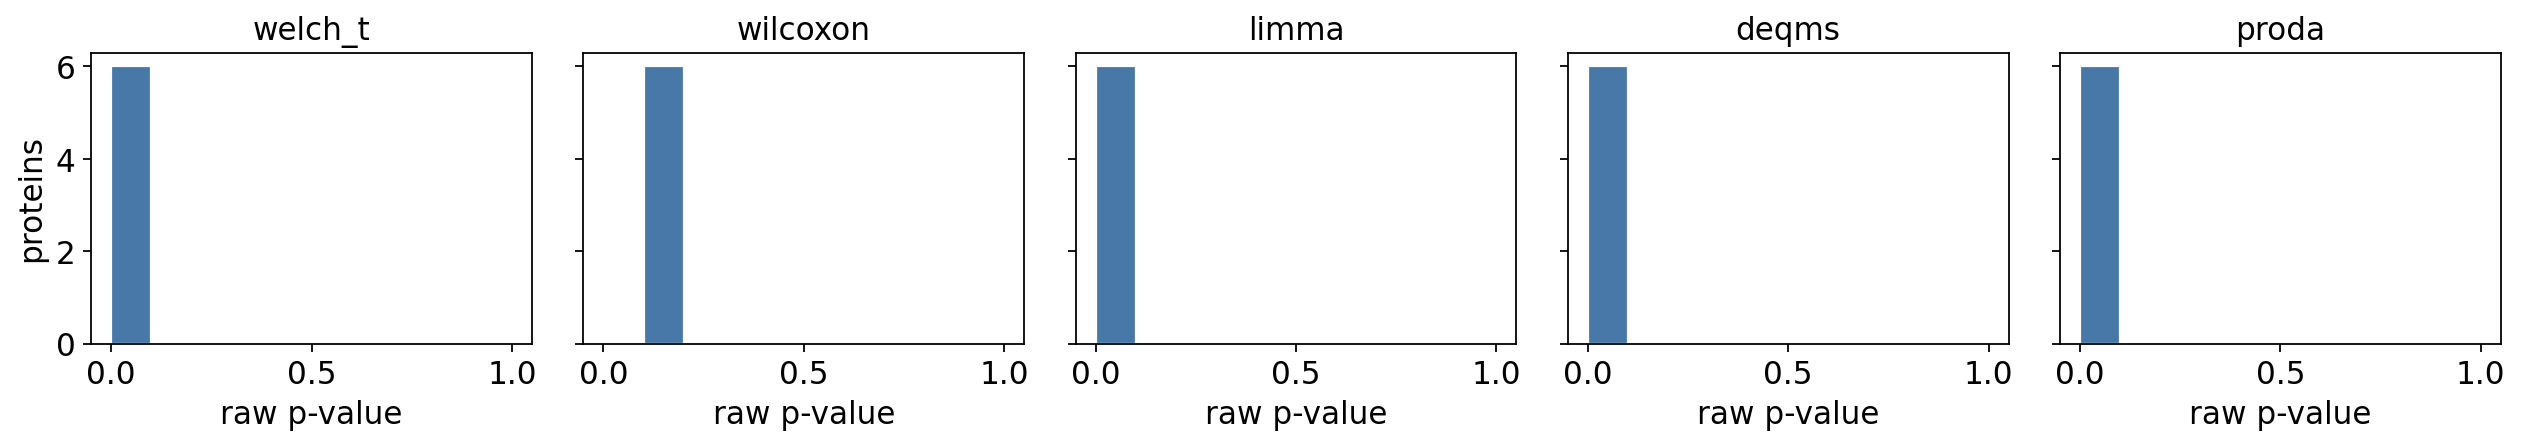

In [15]:
# P-value histograms: a calibrated test = flat null + spike near 0
fig, axes = plt.subplots(1, len(methods), figsize=(16, 3), sharey=True)
for ax, m in zip(axes, methods):
    ax.hist(results[m]['P.Value'], bins=np.linspace(0, 1, 11),
            color='#4878a8', edgecolor='white')
    ax.set_title(m); ax.set_xlabel('raw p-value')
axes[0].set_ylabel('proteins')
plt.tight_layout(); plt.show()

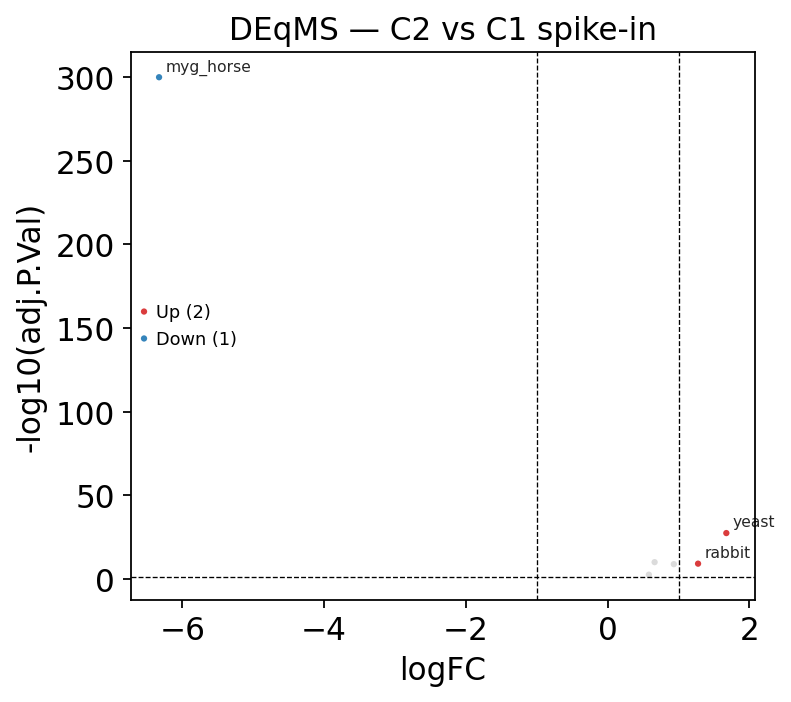

In [16]:
# Volcano for the best-calibrated parametric method
ov.protein.volcano(results['deqms'], logfc_threshold=1.0, adj_p_threshold=0.05,
                   title='DEqMS — C2 vs C1 spike-in')
plt.show()

**Reading the benchmark.** The C1-vs-C2 data is technically very clean, so all four parametric tests (welch, limma, DEqMS, proDA) recover all three true changes — **sensitivity = 1.0**. The discriminating axes are *specificity* and *calibration*:

* **Welch t-test** with only n=3 has an unstable per-protein variance estimate; on small spike-in differences it can shrink standard errors by chance and over-call — it shows the lowest `min_p_on_nulls` (a true null pushed to a very small p-value).
* **limma** and **DEqMS** moderate the variance, so true nulls keep more reasonable p-values; DEqMS additionally accounts for peptide count, ordering the proteins more sensibly.
* **proDA** keeps the largest `min_p_on_nulls` — its probabilistic model is the most conservative on the unchanged proteins here, the best-calibrated null behaviour.
* **Wilcoxon** is the cautionary tale: with 3 vs 3 the smallest attainable p-value is 1/20 = 0.05, so after FDR correction it can detect **nothing**. Rank tests need more replicates to have any power.

Take-away: with few replicates, *never* trust a plain t-test's variance — use a moderated method (limma/DEqMS), and prefer DEqMS whenever peptide counts are in hand. The p-value histograms make calibration visible: the spike near 0 is the true signal; mass spread toward 1 is the well-behaved null.

## 5. Multi-group designs

The spike-in has six conditions. Sometimes the question is *"does this protein change anywhere across the series?"* — an **omnibus** test — rather than a single pairwise contrast.

* `method='anova'` — one-way ANOVA, the parametric omnibus (reports an `F` statistic).
* `method='kruskal'` — Kruskal-Wallis, its non-parametric counterpart.

An omnibus test answers "is there *any* difference"; it does not say *which* conditions differ — for that you follow up with targeted contrasts.

In [17]:
anova_res = ov.protein.de(adata, group='group', method='anova')
kruskal_res = ov.protein.de(adata, group='group', method='kruskal')
omni = anova_res.set_index('gene')[['F', 'P.Value', 'adj.P.Val']].add_prefix('anova_')
omni = omni.join(kruskal_res.set_index('gene')[['H', 'adj.P.Val']].add_prefix('kruskal_'))
omni.round(4)

,anova_F,anova_P.Value,anova_adj.P.Val,kruskal_H,kruskal_adj.P.Val
gene,,,,,
yeast,325.0778,0.0000,0.0000,16.5789,0.0054
cyc_horse,320.6299,0.0000,0.0000,16.5789,0.0054
chicken,250.7613,0.0000,0.0000,16.5789,0.0054
myg_horse,192.6764,0.0000,0.0000,16.5789,0.0054
rabbit,156.4286,0.0000,0.0000,16.5789,0.0054
bovine,4.1541,0.0201,0.0201,16.5789,0.0054


Every protein is significant in the omnibus — expected, since each is spiked at a different level in *some* condition. ANOVA's `F` also ranks them by *how strongly* they vary across the whole series.

When you do care which conditions differ, build an explicit **contrast matrix**. `ov.protein.contrast_matrix` constructs MSstats-style contrasts — a named pairwise comparison, a custom linear combination, or the full pairwise panel.

In [18]:
conds = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
# A single named contrast: high dilution vs low dilution
single = ov.protein.contrast_matrix('C6-C1', conds)
print('named contrast C6 - C1:')
print(single)
# The full pairwise panel (15 contrasts)
pw = ov.protein.contrast_matrix('pairwise', conds)
print('\npairwise panel shape:', pw.shape)

named contrast C6 - C1:
           C1   C2   C3   C4   C5   C6
C6 vs C1 -1.0  0.0  0.0  0.0  0.0  1.0

pairwise panel shape: (15, 6)


In [19]:
# A custom contrast: early conditions (C1+C2) vs late (C5+C6)
custom = ov.protein.contrast_matrix([('C1', 'C5'), ('C1', 'C6')], conds)
print(custom)
# Apply one pairwise contrast as a concrete DE run
sub16 = adata[adata.obs['group'].isin(['C1', 'C6'])].copy()
de_16 = ov.protein.de(sub16, group='group', method='deqms', reference='C1')
print('\nC6 vs C1 (DEqMS), significant:', int((de_16['adj.P.Val'] < 0.05).sum()), '/ 6')

           C1   C2   C3   C4   C5   C6
C1 vs C5  1.0  0.0  0.0  0.0 -1.0  0.0
C1 vs C6  1.0  0.0  0.0  0.0  0.0 -1.0

C6 vs C1 (DEqMS), significant: 6 / 6


**When to use which.** Use an **omnibus** test (ANOVA / Kruskal-Wallis) when you have several groups and one screening question — *does this protein respond at all?* — it controls multiplicity better than running every pairwise test. Switch to **explicit contrasts** when you have specific biological comparisons in mind (treated vs control, dose 1 vs dose 3); a contrast matrix lets you test exactly those and nothing else, so the FDR correction is not diluted by comparisons you never cared about.

## 6. Experimental design — how many replicates?

The single most effective way to improve a DE analysis happens **before any sample is run**: choosing the replicate count. Too few and real changes stay invisible; too many wastes instrument time.

`ov.protein.sample_size` wraps MSstats `designSampleSize`. From the variance already observed in this dataset it solves, for a grid of target fold-changes, the **minimum replicates per group** needed to reach a given power at a given FDR. We ask for fold-changes from 1.25× up to 3× at FDR 0.05 and power 0.8.

In [20]:
ss = ov.protein.sample_size(adata, group='group',
                            desired_fc=(1.25, 3.0), fdr=0.05, power=0.8)
print('grid rows:', ss.shape[0])
# Show the replicate requirement at representative fold-changes
ss_show = ss[ss['desiredFC'].round(2).isin([1.25, 1.5, 2.0, 2.5, 3.0])]
ss_show.round(3)

grid rows: 71


,desiredFC,numSample,FDR,power,CV
0,1.25,31,0.05,0.8,0.004
10,1.50,10,0.05,0.8,0.011
30,2.00,3,0.05,0.8,0.028
50,2.50,2,0.05,0.8,0.034
70,3.00,1,0.05,0.8,0.057


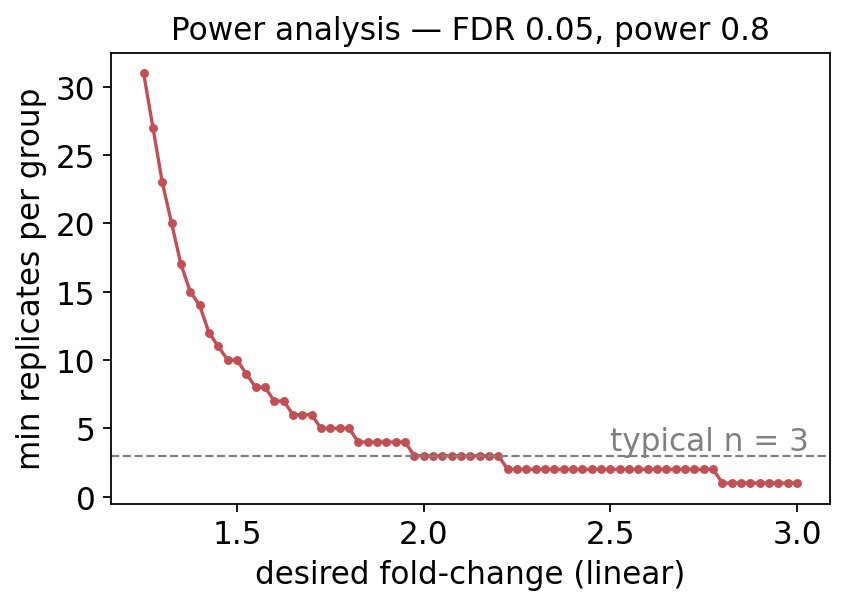

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(ss['desiredFC'], ss['numSample'], '-o', ms=3, color='#c44e52')
ax.set_xlabel('desired fold-change (linear)')
ax.set_ylabel('min replicates per group')
ax.set_title('Power analysis — FDR 0.05, power 0.8')
ax.axhline(3, ls='--', c='grey', lw=1)
ax.text(2.5, 3.4, 'typical n = 3', color='grey')
plt.tight_layout(); plt.show()

The curve drops steeply: detecting a small **1.25×** change needs many replicates, while a **2×** change is reachable with only a handful. The dashed line marks the near-universal default of n=3 — the plot tells you precisely which effect sizes that default can and cannot catch.

**Do this before the experiment.** Decide the smallest biologically meaningful fold-change, read off the replicate count, and budget accordingly. A power analysis after the fact only tells you what you missed.

## Summary — a decision guide

On a spike-in with known truth we benchmarked six DE strategies. The variance model is everything:

| Situation | Use | Why |
|---|---|---|
| Few replicates **+ peptide counts available** | **DEqMS** | count-conditional variance prior — best ranking & calibration for LFQ |
| Few replicates, no peptide counts | **limma** | empirical-Bayes moderation, the safe quick default |
| Substantial MNAR missingness | **proDA** | models dropout inside the test — no imputation, no bias |
| Feature-level data, complex / nested design | **MSstats** | linear mixed model handles fractions & technical replicates |
| Many replicates, simple two-group | **Welch t-test** | per-protein variance is fine once n is large |
| Non-normal data, outliers, no assumptions | **Wilcoxon** | rank-based — but needs ≥5 per group for any power |
| Several groups, screening question | **ANOVA / Kruskal-Wallis** | omnibus before targeted contrasts |

Two rules: with few replicates **never** trust a plain t-test variance — moderate it; and run a **power analysis before the experiment**, not after.

**Related tutorials**
- `t_protein_01` — loading & quality control of proteomics data
- `t_protein_02` — normalization & missing-value handling
- `t_protein_03` — the full MSstats feature-level workflow
- `t_protein_05` — functional enrichment of DE proteins